# Chapter 05 - Classification

## Objectives
Learn how models classify observations into categories. Covers logistic regression, confusion matrix, ROC-AUC, precision-recall, imbalanced data, and decision boundaries.

## Core Theory
Classification predicts labels such as spam/not spam, fraud/not fraud, disease/no disease. Unlike regression, output is categorical.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
X,y=make_classification(n_samples=700,n_features=2,n_redundant=0,n_informative=2,
n_clusters_per_class=1,class_sep=1.4,weights=[0.65,0.35],random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
clf=LogisticRegression().fit(X_train,y_train)
proba=clf.predict_proba(X_test)[:,1]
pred=(proba>=0.5).astype(int)

## 1. Data Visualization

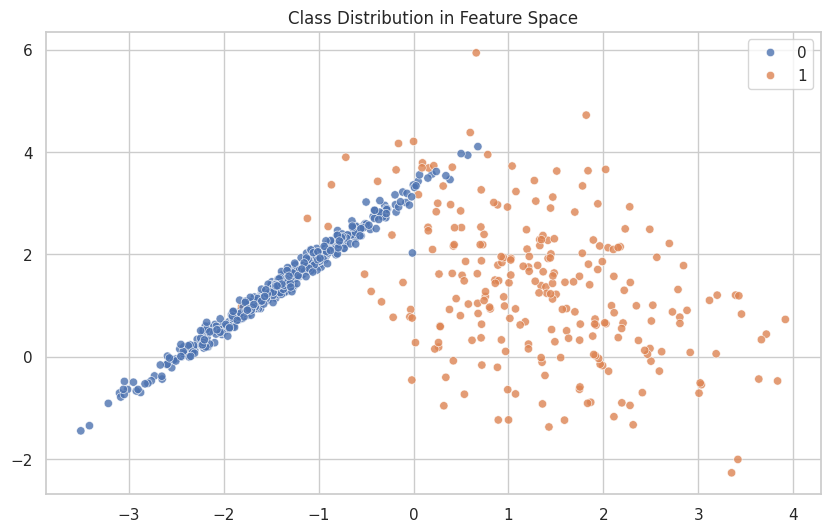

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,palette='deep',alpha=.8)
plt.title('Class Distribution in Feature Space')
plt.show()

## 2. Logistic Regression Probability Curve
Logistic regression outputs probabilities between 0 and 1.

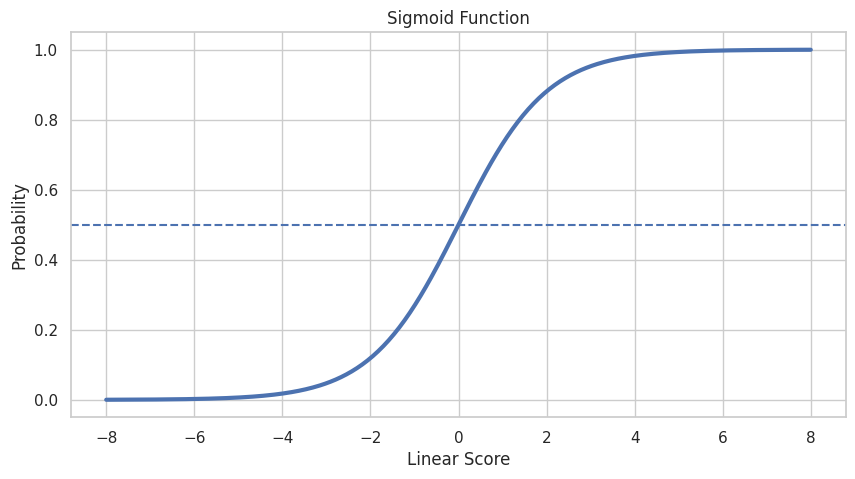

In [4]:
z=np.linspace(-8,8,400)
sig=1/(1+np.exp(-z))
plt.figure(figsize=(10,5))
plt.plot(z,sig,lw=3)
plt.axhline(0.5,ls='--')
plt.title('Sigmoid Function')
plt.xlabel('Linear Score'); plt.ylabel('Probability')
plt.show()

## 3. Decision Boundary

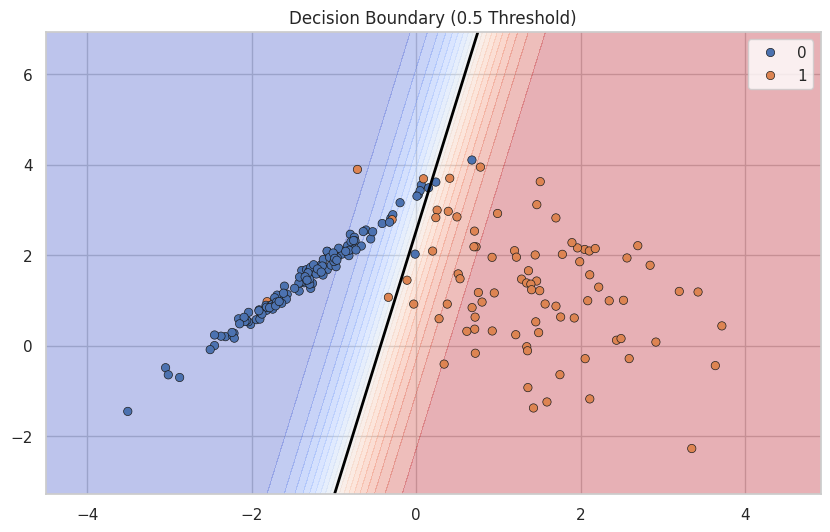

In [5]:
xx,yy=np.meshgrid(np.linspace(X[:,0].min()-1,X[:,0].max()+1,250),
np.linspace(X[:,1].min()-1,X[:,1].max()+1,250))
grid=np.c_[xx.ravel(),yy.ravel()]
zz=clf.predict_proba(grid)[:,1].reshape(xx.shape)
plt.figure(figsize=(10,6))
plt.contourf(xx,yy,zz,levels=20,alpha=.35,cmap='coolwarm')
plt.contour(xx,yy,zz,levels=[0.5],colors='black',linewidths=2)
sns.scatterplot(x=X_test[:,0],y=X_test[:,1],hue=y_test,edgecolor='k')
plt.title('Decision Boundary (0.5 Threshold)')
plt.show()

## 4. Confusion Matrix
Shows TP, TN, FP, FN.

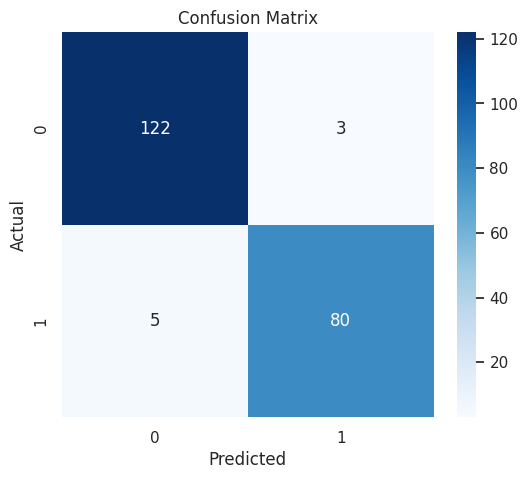

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       125
           1       0.96      0.94      0.95        85

    accuracy                           0.96       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.96      0.96      0.96       210



In [6]:
cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()
print(classification_report(y_test,pred))

## 5. ROC Curve & AUC

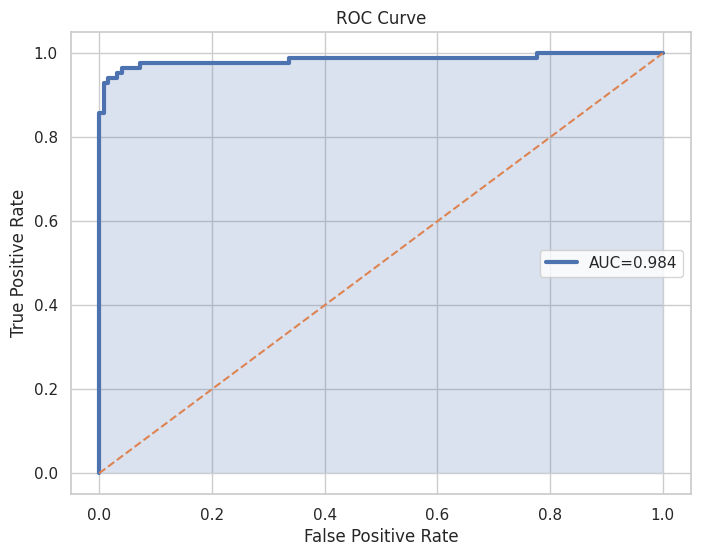

In [7]:
fpr,tpr,_=roc_curve(y_test,proba)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,lw=3,label=f'AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.fill_between(fpr,tpr,alpha=.2)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.show()

## 6. Precision-Recall Curve
Useful for imbalanced datasets.

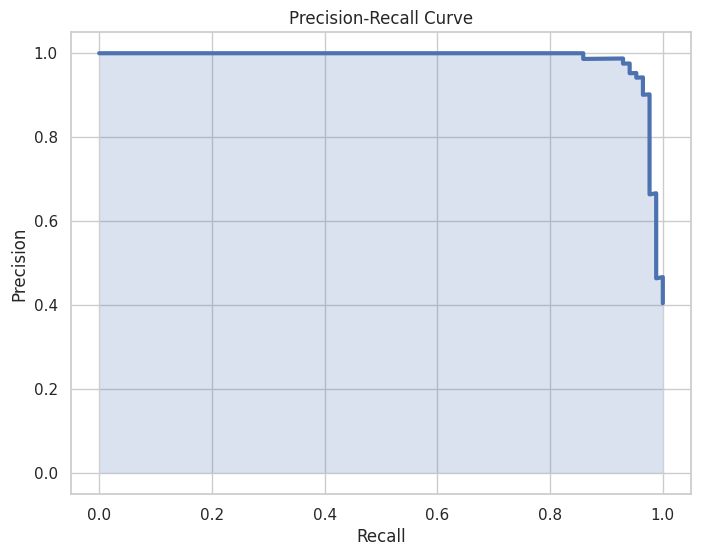

In [8]:
prec,rec,_=precision_recall_curve(y_test,proba)
plt.figure(figsize=(8,6))
plt.plot(rec,prec,lw=3)
plt.fill_between(rec,prec,alpha=.2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.show()

## 7. Compare Models

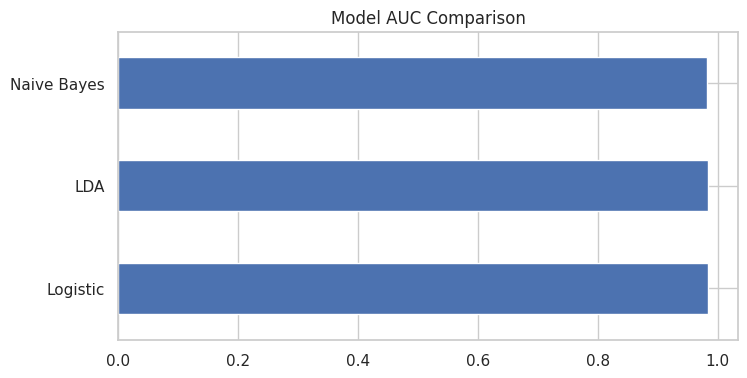

In [9]:
nb=GaussianNB().fit(X_train,y_train)
lda=LinearDiscriminantAnalysis().fit(X_train,y_train)
models={'Logistic':clf,'Naive Bayes':nb,'LDA':lda}
scores={}
for k,m in models.items():
    p=m.predict_proba(X_test)[:,1]
    scores[k]=auc(*roc_curve(y_test,p)[:2])
pd.Series(scores).sort_values(ascending=False).plot(kind='barh',figsize=(8,4),title='Model AUC Comparison')
plt.show()

## Key Concepts
- Threshold changes precision and recall.
- Accuracy alone can mislead with rare classes.
- ROC-AUC measures ranking ability.
- Precision matters when false positives are costly.
- Recall matters when false negatives are costly.

## Key Takeaways
1. Classification predicts labels.
2. Logistic regression is interpretable and strong baseline.
3. Use confusion matrix + ROC + PR curves together.
4. Class imbalance needs careful metrics.
5. Decision threshold should match business cost.